In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [25]:
# read csv file
df = pd.read_csv('members.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   member_id              100 non-null    int64 
 1   member_age             100 non-null    int64 
 2   member_gender          100 non-null    object
 3   plan_type              100 non-null    object
 4   enrollment_start_date  100 non-null    object
 5   enrollment_end_date    85 non-null     object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB


In [26]:
# change data type on enroolment dates
df['enrollment_start_date'] = pd.to_datetime(df['enrollment_start_date'])
df['enrollment_end_date'] = pd.to_datetime(df['enrollment_end_date'])

In [27]:
df[['enrollment_start_date','enrollment_end_date']]

,enrollment_start_date,enrollment_end_date
0,2021-05-14,2023-11-30
1,2020-03-22,2022-08-15
2,2022-01-10,2024-04-01
3,2020-09-05,2022-12-01
4,2023-02-28,NaT
...,...,...
95,2022-04-18,2024-06-30
96,2020-12-01,2022-08-19
97,2023-08-07,2025-01-01
98,2021-06-20,2022-11-30


In [28]:
# duration contract
df['enrollment_gap']= df['enrollment_end_date'] - df['enrollment_start_date']

In [29]:
# read 2nd csv fild
df2 = pd.read_csv('claims.csv')
df2.head()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 449 entries, 0 to 448
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   claim_id       449 non-null    int64  
 1   member_id      449 non-null    int64  
 2   provider_id    449 non-null    object 
 3   claim_date     449 non-null    object 
 4   claim_type     449 non-null    object 
 5   cpt_code       449 non-null    object 
 6   icd_code       449 non-null    object 
 7   billed_amount  449 non-null    float64
 8   paid_amount    449 non-null    float64
dtypes: float64(2), int64(2), object(5)
memory usage: 31.7+ KB


In [30]:
# modify claim date type
df2['claim_date'] = pd.to_datetime(df2['claim_date'])

In [31]:
# merge two date
df_merge = pd.merge(df,df2,on='member_id')

In [32]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 449 entries, 0 to 448
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype          
---  ------                 --------------  -----          
 0   member_id              449 non-null    int64          
 1   member_age             449 non-null    int64          
 2   member_gender          449 non-null    object         
 3   plan_type              449 non-null    object         
 4   enrollment_start_date  449 non-null    datetime64[ns] 
 5   enrollment_end_date    381 non-null    datetime64[ns] 
 6   enrollment_gap         381 non-null    timedelta64[ns]
 7   claim_id               449 non-null    int64          
 8   provider_id            449 non-null    object         
 9   claim_date             449 non-null    datetime64[ns] 
 10  claim_type             449 non-null    object         
 11  cpt_code               449 non-null    object         
 12  icd_code               449 non-null    object     

In [33]:
# identify missing data
df_merge.isnull().sum()/df_merge.shape[0]

,0
member_id,0.000000
member_age,0.000000
member_gender,0.000000
plan_type,0.000000
enrollment_start_date,0.000000
enrollment_end_date,0.151448
enrollment_gap,0.151448
claim_id,0.000000
provider_id,0.000000
claim_date,0.000000


In [34]:
# explore memeber ages
df_merge['member_age'].describe()

,member_age
count,449.000000
mean,48.064588
std,14.825859
min,21.000000
25%,37.000000
50%,45.000000
75%,58.000000
max,94.000000


In [35]:
df_merge['member_age'].describe()

,member_age
count,449.000000
mean,48.064588
std,14.825859
min,21.000000
25%,37.000000
50%,45.000000
75%,58.000000
max,94.000000


In [36]:
# download merge csv file
df_merge.to_csv('merge.csv',index=False)

In [37]:
# Find out total paie amount per memeber_id
df_merge.groupby('member_id')['paid_amount'].sum().sort_values(ascending=False).head(10)

,paid_amount
member_id,
6,43300.00
32,40080.00
58,35920.00
82,30690.00
28,30560.00
20,30375.00
71,30230.00
1,30120.00
36,25530.75


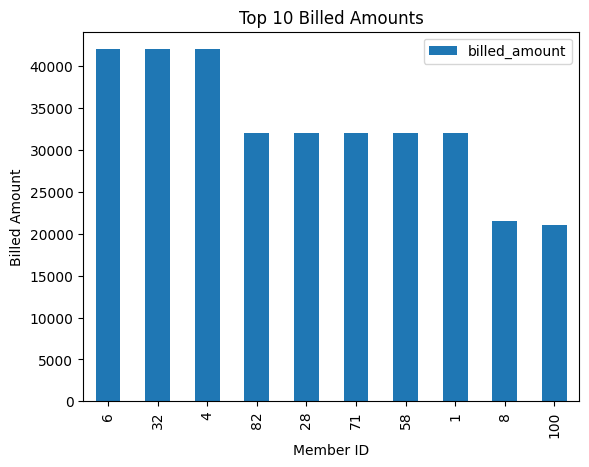

In [38]:
# Visualize top 10 billed amounts
top_10_billed = df_merge.sort_values('billed_amount', ascending = False).head(10)
top_10_billed.plot(kind='bar', x='member_id', y='billed_amount', title='Top 10 Billed Amounts')
plt.ylabel('Billed Amount')
plt.xlabel('Member ID')
plt.show()

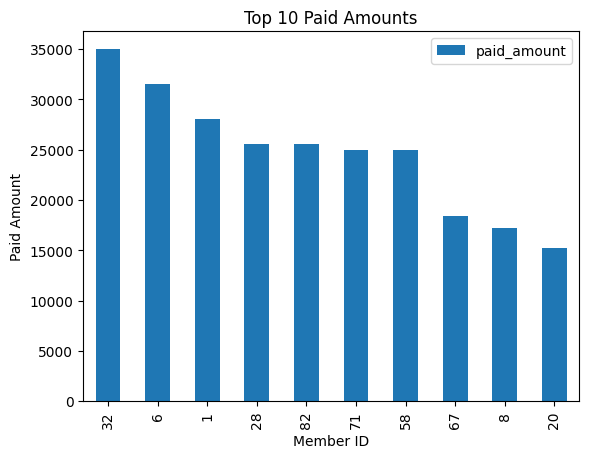

In [40]:
# Visualize top 10 paid amounts
top_10_billed = df_merge.sort_values('paid_amount', ascending = False).head(10)
top_10_billed.plot(kind='bar', x='member_id', y='paid_amount', title='Top 10 Paid Amounts')
plt.ylabel('Paid Amount')
plt.xlabel('Member ID')
plt.show()

In [41]:
# feature engineering # create claim frequency
df_merge['claim_frequency'] = df_merge.groupby('member_id')['claim_id'].transform('count')

In [42]:
# create cost claim ratios
df_merge['cost_claim_ratio'] = df_merge['billed_amount'] / df_merge['claim_frequency']

In [43]:
df_merge.head()

,member_id,member_age,member_gender,plan_type,enrollment_start_date,enrollment_end_date,enrollment_gap,claim_id,provider_id,claim_date,claim_type,cpt_code,icd_code,billed_amount,paid_amount,claim_frequency,cost_claim_ratio
0,1,45,F,PPO,2021-05-14,2023-11-30,930 days,1,PRV00001,2023-03-12,Outpatient,12345,A12.3,1800.0,1600.0,4,450.0
1,1,45,F,PPO,2021-05-14,2023-11-30,930 days,2,PRV00002,2023-07-22,Inpatient,67890,B99.4,32000.0,28000.0,4,8000.0
2,1,45,F,PPO,2021-05-14,2023-11-30,930 days,3,PRV00003,2024-01-15,Lab,23456,C50.1,450.0,400.0,4,112.5
3,1,45,F,PPO,2021-05-14,2023-11-30,930 days,4,PRV00004,2023-09-05,Pharmacy,34567,D12.7,120.0,120.0,4,30.0
4,2,52,M,HMO,2020-03-22,2022-08-15,876 days,5,PRV00123,2023-04-12,Outpatient,12345,A12.3,2100.0,1680.0,4,525.0


In [44]:
# machine learning for predict enrolled end date
df_merge['enrollment_end_ordinal'] = (
    df_merge['enrollment_end_date']
         .map(lambda x: x.toordinal() if pd.notnull(x) else None)
)

In [45]:

date_feature_cols = [
    'enrollment_start_date',
    'claim_date'
]

In [46]:
date_cols = [
    'enrollment_start_date',
    'enrollment_end_date',    # for training only (not for prediction!)
    'claim_date'
]

In [47]:
cat_cols = [
    'member_gender', 'plan_type',
    'provider_id', 'claim_type',
    'cpt_code', 'icd_code'
]


In [48]:
def extract_date_features(X):
    # Convert NumPy array to DataFrame with correct column names
    df = pd.DataFrame(X, columns=date_feature_cols)

    out = pd.DataFrame()

    for col in df.columns:
        s = pd.to_datetime(df[col], errors='coerce')

        out[col + "_year"]    = s.dt.year
        out[col + "_month"]   = s.dt.month
        out[col + "_day"]     = s.dt.day
        out[col + "_dow"]     = s.dt.dayofweek
        out[col + "_ordinal"] = s.map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)

    return out

In [49]:
from sklearn.preprocessing import FunctionTransformer
date_transformer = FunctionTransformer(
    extract_date_features,
    validate=False,
    feature_names_out="one-to-one"
)


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_cols = [
    'member_id', 'member_age', 'enrollment_gap', 'claim_id',
    'billed_amount', 'paid_amount','claim_frequency','cost_claim_ratio'
]

preprocess = ColumnTransformer(
    transformers=[
        ("date", FunctionTransformer(extract_date_features), date_feature_cols),
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])

In [52]:
train_df = df_merge[df_merge['enrollment_end_ordinal'].notnull()]
test_df  = df_merge[df_merge['enrollment_end_ordinal'].isnull()]

In [53]:
df_merge.columns.tolist()

['member_id',
 'member_age',
 'member_gender',
 'plan_type',
 'enrollment_start_date',
 'enrollment_end_date',
 'enrollment_gap',
 'claim_id',
 'provider_id',
 'claim_date',
 'claim_type',
 'cpt_code',
 'icd_code',
 'billed_amount',
 'paid_amount',
 'claim_frequency',
 'cost_claim_ratio',
 'enrollment_end_ordinal']

In [54]:
train_df['enrollment_gap_days'] = train_df['enrollment_gap'].dt.days.astype(float)
test_df['enrollment_gap_days'] = test_df['enrollment_gap'].dt.days.astype(float)

num_cols = [
    'member_id', 'member_age', 'claim_id',
    'billed_amount', 'paid_amount'
]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer

preprocess = ColumnTransformer(
    transformers=[
        ("date", FunctionTransformer(extract_date_features), date_feature_cols),
        ("num", "passthrough", num_cols), # Use the updated numerical columns
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])

# Now, fit the pipeline with the modified data.
pipeline.fit(train_df, train_df['enrollment_end_ordinal'])

/tmp/ipykernel_507/202529883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['enrollment_gap_days'] = train_df['enrollment_gap'].dt.days.astype(float)
/tmp/ipykernel_507/202529883.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['enrollment_gap_days'] = test_df['enrollment_gap'].dt.days.astype(float)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('date',
                                                  FunctionTransformer(func=<function extract_date_features at 0x7c865d4fafc0>),
                                                  ['enrollment_start_date',
                                                   'claim_date']),
                                                 ('num', 'passthrough',
                                                  ['member_id', 'member_age',
                                                   'claim_id', 'billed_amount',
                                                   'paid_amount']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['member_gender', 'plan_type',
                                                   'provider_id', 'claim_type',
                                                   'cpt_code', 'icd_code'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [55]:
from datetime import date

# Predict raw values
pred_ordinals = pipeline.predict(test_df)

# Clip predictions
min_ordinal = 700000
max_ordinal = 800000
pred_ordinals_clipped = np.clip(pred_ordinals, min_ordinal, max_ordinal)

# Convert using Python's date.fromordinal -> ALWAYS WORKS
predicted_dates = [
    date.fromordinal(int(x)) for x in pred_ordinals_clipped
]

# Convert to pandas datetime
predicted_dates = pd.to_datetime(predicted_dates)

# Initialize 'enrollment_end_date_predicted' column in df_merge if it doesn't exist
# This ensures that .loc doesn't try to assign to a non-existent column without creating it first
if 'enrollment_end_date_predicted' not in df_merge.columns:
    df_merge['enrollment_end_date_predicted'] = pd.NaT

# Assign back into df_merge (assuming df_final was meant to be df_merge)
df_merge.loc[
    df_merge['enrollment_end_ordinal'].isnull(),
    'enrollment_end_date_predicted'
] = predicted_dates

predicted_dates[:10]

DatetimeIndex(['2024-03-07', '2024-03-07', '2024-03-06', '2023-07-08',
               '2023-07-20', '2023-07-07', '2023-07-07', '2023-07-10',
               '2024-10-12', '2024-10-13'],
              dtype='datetime64[ns]', freq=None)

In [56]:
pred_ordinals = pipeline.predict(test_df)

In [57]:
min_ordinal = 700000      # ~ year 1915
max_ordinal = 800000      # ~ year 2192

pred_ordinals_clipped = np.clip(pred_ordinals, min_ordinal, max_ordinal)

In [58]:
redicted_dates = [
    date.fromordinal(int(x)) for x in pred_ordinals_clipped
]

predicted_dates = pd.to_datetime(predicted_dates)

In [59]:
df_merge.loc[
    df_merge['enrollment_end_ordinal'].isnull(),
    'enrollment_end_date'
] = predicted_dates


In [60]:
df_merge['enrollment_end_date_predicted'] = df_merge['enrollment_end_date']

In [61]:
df_merge[df_merge['claim_id']==94]

,member_id,member_age,member_gender,plan_type,enrollment_start_date,enrollment_end_date,enrollment_gap,claim_id,provider_id,claim_date,claim_type,cpt_code,icd_code,billed_amount,paid_amount,claim_frequency,cost_claim_ratio,enrollment_end_ordinal,enrollment_end_date_predicted
88,20,35,M,EPO,2020-12-01,2022-04-08,NaT,94,PRV00008,2024-04-02,Inpatient,89012,I10,18000.0,15250.0,8,2250.0,NaN,2022-04-08


In [62]:
# ---------------------------------------
# Extract feature names from the pipeline
# ---------------------------------------
def get_feature_names(preprocessor):
    feature_names = []

    for name, transformer, columns in preprocessor.transformers_:
        if name == 'date':
            # our FunctionTransformer outputs numeric date features
            for col in columns:
                feature_names.extend([
                    f"{col}_year",
                    f"{col}_month",
                    f"{col}_day",
                    f"{col}_dow",
                    f"{col}_ordinal"
                ])

        elif name == 'num':
            feature_names.extend(columns)

        elif name == 'cat':
            ohe = transformer
            feature_names.extend(ohe.get_feature_names_out(columns))

    return feature_names

# Get names
feature_names = get_feature_names(pipeline.named_steps['preprocess'])

# ---------------------------------------
# Extract importance from RandomForest
# ---------------------------------------
importances = pipeline.named_steps['model'].feature_importances_

# Put into a DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

importance_df.head(20)

,feature,importance
4,enrollment_start_date_ordinal,0.469859
0,enrollment_start_date_year,0.275136
11,member_age,0.036490
10,member_id,0.036132
12,claim_id,0.033889
2,enrollment_start_date_day,0.027369
1,enrollment_start_date_month,0.026929
3,enrollment_start_date_dow,0.016297
172,cpt_code_36415,0.013699
240,icd_code_A12.34,0.011542


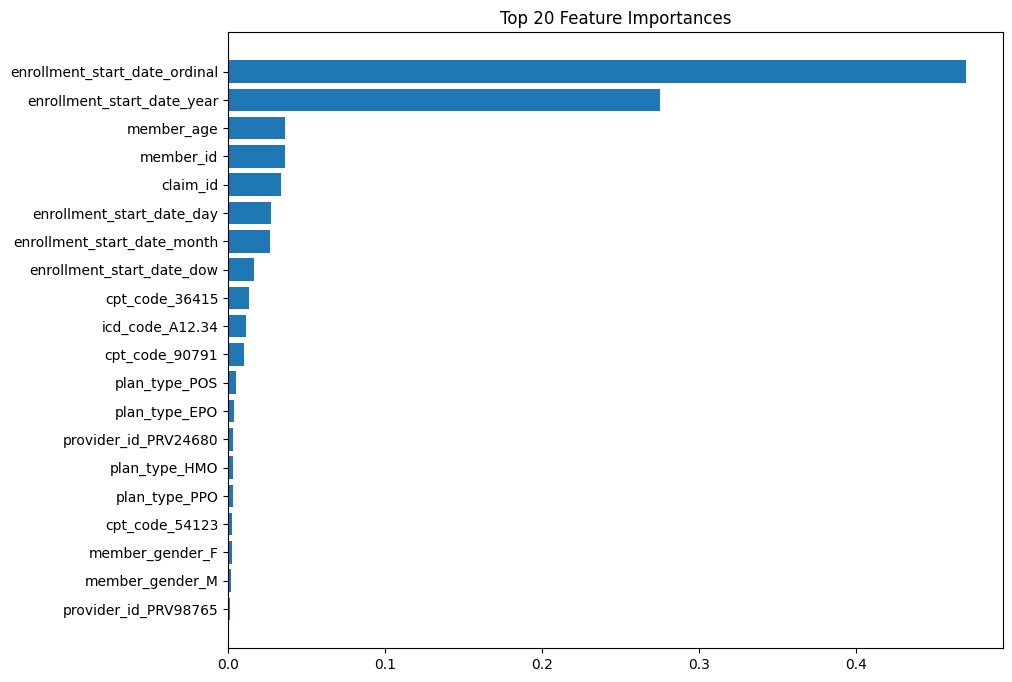

In [63]:
top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'].head(top_n), importance_df['importance'].head(top_n))
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.show()

In [64]:
# === EVALUATION: define y_true / y_pred, then compute metrics ===
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

assert 'pipeline' in globals(), "pipeline is not defined (fit your model first)"
assert 'train_df' in globals(), "train_df is not defined (split your data first)"
assert 'enrollment_end_ordinal' in train_df.columns, "target column 'enrollment_end_ordinal' not found in train_df"

y_true = train_df['enrollment_end_ordinal'].values
y_pred = pipeline.predict(train_df)

y_true_eval = np.asarray(y_true, dtype=float)
y_pred_eval = np.asarray(y_pred, dtype=float)
mask = np.isfinite(y_true_eval) & np.isfinite(y_pred_eval)
y_true_eval = y_true_eval[mask]
y_pred_eval = y_pred_eval[mask]


mae = mean_absolute_error(y_true_eval, y_pred_eval)
mse = mean_squared_error(y_true_eval, y_pred_eval)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_eval, y_pred_eval)

print("MODEL EVALUATION")
print("------------------------")
print(f"MAE  (days): {mae:.2f}")
print(f"RMSE (days): {rmse:.2f}")
print(f"R² Score   : {r2:.4f}")

MODEL EVALUATION
------------------------
MAE  (days): 11.36
RMSE (days): 30.33
R² Score   : 0.9933


In [65]:
print(type(y_true), type(y_pred))
print(np.shape(y_true), np.shape(y_pred))
print("y_true dtype:", np.asarray(y_true).dtype, " y_pred dtype:", np.asarray(y_pred).dtype)
print("NaNs in y_true:", np.isnan(np.asarray(y_true)).sum(), " NaNs in y_pred:", np.isnan(np.asarray(y_pred)).sum())

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(381,) (381,)
y_true dtype: float64  y_pred dtype: float64
NaNs in y_true: 0  NaNs in y_pred: 0


In [66]:
from datetime import date

y_pred_dates = pd.to_datetime([date.fromordinal(int(x)) for x in y_pred])
y_true_dates = pd.to_datetime([date.fromordinal(int(x)) for x in y_true])

comparison = pd.DataFrame({
    "true_date": y_true_dates,
    "pred_date": y_pred_dates,
    "true_ordinal": y_true,
    "pred_ordinal": y_pred
})

comparison.head(20)

,true_date,pred_date,true_ordinal,pred_ordinal
0,2023-11-30,2023-11-18,738854.0,738842.960000
1,2023-11-30,2023-11-21,738854.0,738845.490000
2,2023-11-30,2023-11-24,738854.0,738848.236667
3,2023-11-30,2023-11-25,738854.0,738849.806667
4,2022-08-15,2022-08-10,738382.0,738377.076667
5,2022-08-15,2022-08-07,738382.0,738374.016667
6,2022-08-15,2022-08-13,738382.0,738380.486667
7,2022-08-15,2022-08-06,738382.0,738373.510000
8,2024-04-01,2024-03-30,738977.0,738975.570000
9,2024-04-01,2024-03-30,738977.0,738975.350000


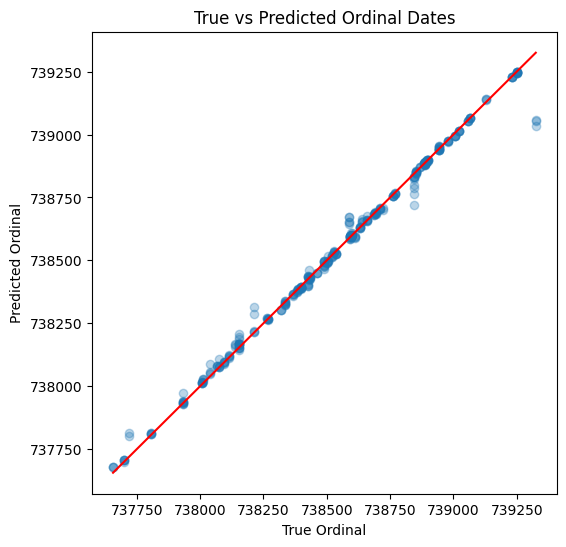

In [67]:
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.3)
plt.xlabel("True Ordinal")
plt.ylabel("Predicted Ordinal")
plt.title("True vs Predicted Ordinal Dates")
plt.plot([min(y_true), max(y_true)],
         [min(y_true), max(y_true)], color="red")
plt.show()